In [16]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [19]:
# Load the clustered dataset directly
df = pd.read_csv('baringo_clustered_data.csv')

# Convert 'time' column to datetime
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4018 entries, 2010-01-01 to 2020-12-31
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     4018 non-null   int64  
 1   temperature    4018 non-null   float64
 2   dew_point      4018 non-null   float64
 3   humidity       4018 non-null   float64
 4   wind_speed     4018 non-null   float64
 5   pressure       4018 non-null   float64
 6   precipitation  4018 non-null   float64
 7   region_id      4018 non-null   int64  
dtypes: float64(6), int64(2)
memory usage: 282.5 KB


In [20]:
# 🔹 Calculate flood probability directly
df['3_day_cum_precip'] = df['precipitation'].rolling(window=3).sum()
df['norm_precip'] = df['3_day_cum_precip'] / df['3_day_cum_precip'].max()
df['norm_humidity'] = df['humidity'] / df['humidity'].max()
df['norm_dew_point'] = df['dew_point'] / df['dew_point'].max()
df['norm_pressure'] = 1 - (df['pressure'] / df['pressure'].max())  # Inverse scaling

df['flood_probability'] = (
    (df['norm_precip'] * 0.5) + 
    (df['norm_humidity'] * 0.2) + 
    (df['norm_dew_point'] * 0.2) + 
    (df['norm_pressure'] * 0.1)
).clip(0, 1)  # Ensure values are between 0 and 1

In [21]:
# Select features for LSTM
features = ['temperature', 'dew_point', 'humidity', 'wind_speed', 'pressure', 'precipitation']
target = 'flood_probability'  # Predicting precipitation as a proxy for flood risk

df.head()

,Unnamed: 0,temperature,dew_point,humidity,wind_speed,pressure,precipitation,region_id,3_day_cum_precip,norm_precip,norm_humidity,norm_dew_point,norm_pressure,flood_probability
time,,,,,,,,,,,,,,
2010-01-01,0,18.0,14.0,85.0,5.0,29.91,23.0,3,NaN,NaN,0.867347,0.823529,0.005982,NaN
2010-01-02,1,18.0,16.0,89.0,6.0,29.94,28.8,3,NaN,NaN,0.908163,0.941176,0.004985,NaN
2010-01-03,2,18.0,14.0,82.0,10.0,29.94,2.5,0,54.3,0.265396,0.836735,0.823529,0.004985,0.465249
2010-01-04,3,18.0,13.0,76.0,9.0,29.94,1.7,2,33.0,0.161290,0.775510,0.764706,0.004985,0.389187
2010-01-05,4,19.0,12.0,69.0,10.0,29.91,1.3,2,5.5,0.026882,0.704082,0.705882,0.005982,0.296032


In [15]:
# 🔹 Normalize input features (min-max scaling)
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

In [17]:
# 🔹 Prepare sequences for LSTM
sequence_length = 10  # Using last 10 days as input for prediction
X, y = [], []

for i in range(sequence_length, len(df)):
    X.append(df[features].iloc[i-sequence_length:i].values)
    y.append(df[target].iloc[i])

X, y = np.array(X), np.array(y)

# 🔹 Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)


In [22]:
# 🔹 Build LSTM Model
model = Sequential([
    Bidirectional(LSTM(50, return_sequences=True), input_shape=(sequence_length, len(features))),
    Dropout(0.4),
    Bidirectional(LSTM(50, return_sequences=False)),
    Dropout(0.4),
    Dense(30, activation='relu'),
    Dense(1, activation='sigmoid')  # Output is between 0 and 1
])

# Compile Model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003)
model.compile(optimizer=optimizer, loss=tf.keras.losses.Huber(), metrics=['mae'])

# Train Model
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test), verbose=1)


2025-02-13 11:08:13.763562: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/ronny/.local/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - loss: 0.0071 - mae: 0.0916 - val_loss: 0.0027 - val_mae: 0.0534
Epoch 2/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0024 - mae: 0.0527 - val_loss: 0.0019 - val_mae: 0.0443
Epoch 3/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0018 - mae: 0.0454 - val_loss: 0.0015 - val_mae: 0.0400
Epoch 4/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0015 - mae: 0.0418 - val_loss: 0.0015 - val_mae: 0.0396
Epoch 5/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0013 - mae: 0.0389 - val_loss: 0.0015 - val_mae: 0.0397
Epoch 6/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0013 - mae: 0.0387 - val_loss: 0.0011 - val_mae: 0.0341
Epoch 7/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0012 - mae: 0.0377 - val_loss: 0.0010 - val_mae: 0.0334
Epoch 8/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.0012 - mae: 0.0363 - val_loss: 9.6783e-04 - val_mae: 0.0329
Epoch 9/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

In [24]:
# 🔹 Model Evaluation
y_pred = model.predict(X_test)

# Convert predictions back to original scale
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"MSE: {mse}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step
RMSE: 0.03869091144399195
MAE: 0.02872071162462868
MSE: 0.0014969866283668274


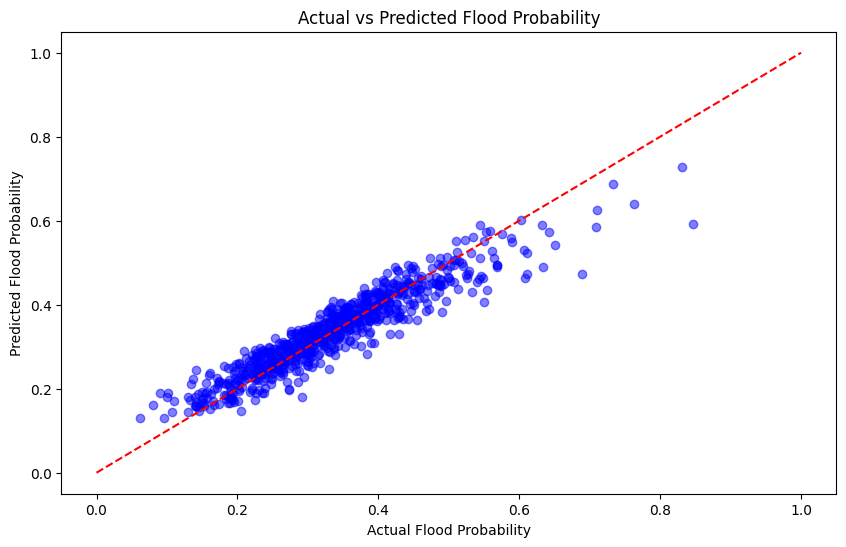

In [25]:
# 🔹 Plot Actual vs Predicted for ALL DATA
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([0, 1], [0, 1], 'r--')  # Perfect prediction line
plt.xlabel("Actual Flood Probability")
plt.ylabel("Predicted Flood Probability")
plt.title("Actual vs Predicted Flood Probability")
plt.show()

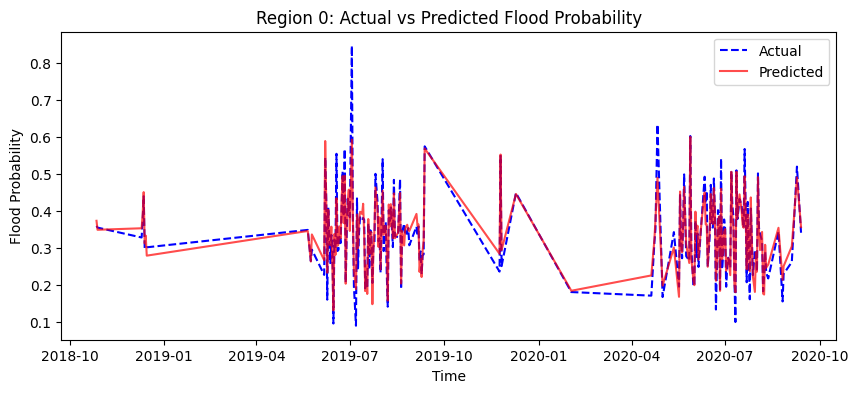

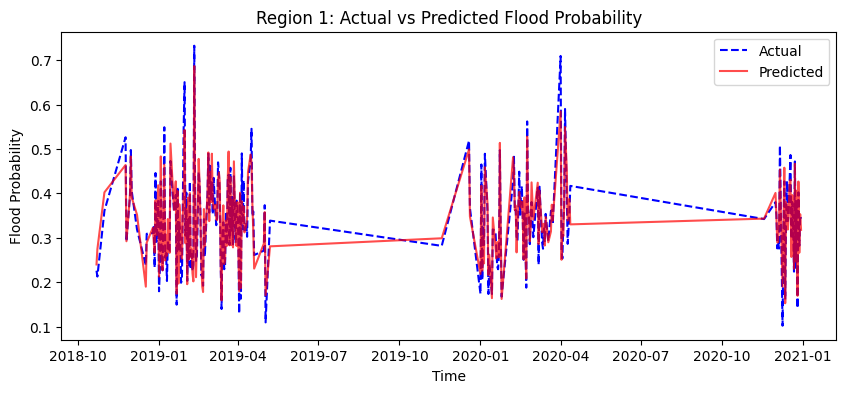

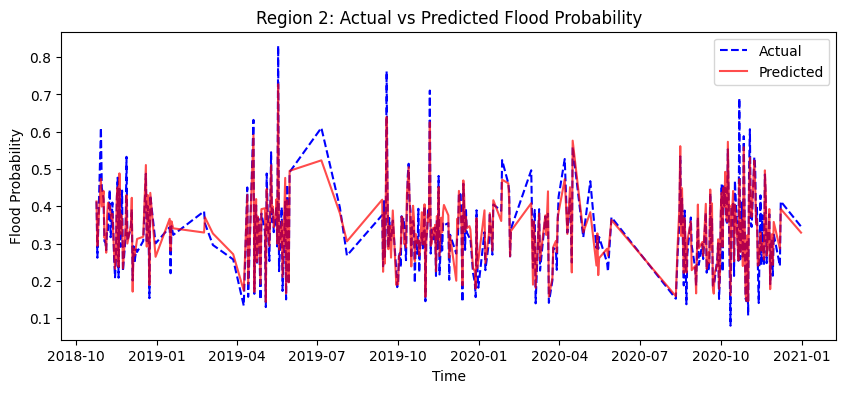

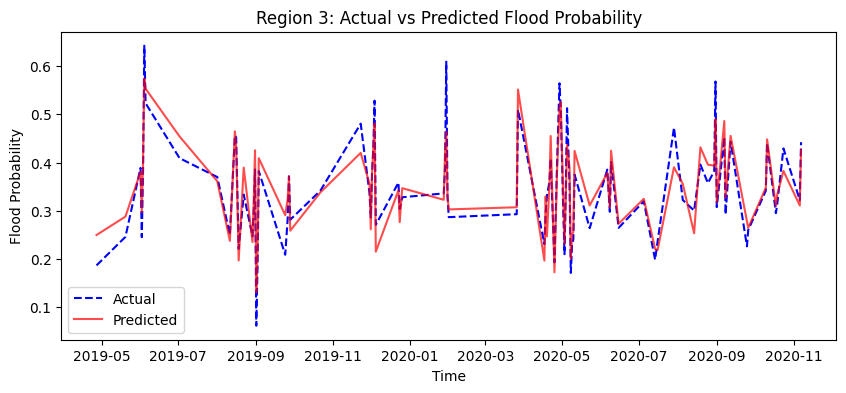

In [30]:
regions_test = df['region_id'].iloc[-len(y_test):].values  # Extract region IDs

regions_unique = np.unique(regions_test)  # Get unique regions

for region in regions_unique:
    plt.figure(figsize=(10, 4))
    
    mask = (regions_test == region)  # Filter data for each region
    
    plt.plot(df.index[-len(y_test):][mask], y_test[mask], linestyle='dashed', color='blue', label="Actual")
    plt.plot(df.index[-len(y_test):][mask], y_pred[mask], color='red', alpha=0.7, label="Predicted")
    
    plt.legend()
    plt.title(f"Region {region}: Actual vs Predicted Flood Probability")
    plt.xlabel("Time")
    plt.ylabel("Flood Probability")
    
    plt.show()


In [31]:
# Ensure y_test and y_pred are 1D arrays
y_test_flat = np.array(y_test).flatten()
y_pred_flat = np.array(y_pred).flatten()
regions_flat = np.array(regions_test).flatten()

# Convert predictions and actual values into a DataFrame for easy comparison
results_df = pd.DataFrame({
    "Date": df.index[-len(y_test_flat):],  # Match the test set length
    "Region": regions_flat,
    "Actual Flood Probability": y_test_flat,
    "Predicted Flood Probability": y_pred_flat
})

# Display a random sample of 10 rows
sample_results = results_df.sample(10, random_state=42)  # Set seed for reproducibility
print(sample_results)


          Date  Region  Actual Flood Probability  Predicted Flood Probability
192 2019-05-02       1                  0.109362                     0.170399
294 2019-08-12       0                  0.302525                     0.326432
168 2019-04-08       1                  0.316544                     0.312060
521 2020-03-26       3                  0.293013                     0.307389
535 2020-04-09       1                  0.286285                     0.338745
788 2020-12-18       1                  0.486366                     0.430457
591 2020-06-04       0                  0.338954                     0.360261
323 2019-09-10       0                  0.279661                     0.292622
218 2019-05-28       2                  0.457548                     0.415896
405 2019-12-01       3                  0.286171                     0.261683


In [35]:
# Filter cases where predicted flood probability is above 80%
high_risk_floods = results_df[results_df["Predicted Flood Probability"] > 0.55]

# Display the high-risk cases
print(high_risk_floods)


          Date  Region  Actual Flood Probability  Predicted Flood Probability
111 2019-02-10       1                  0.732465                     0.686731
180 2019-04-20       2                  0.631659                     0.590890
208 2019-05-18       2                  0.830564                     0.727252
225 2019-06-04       3                  0.641923                     0.574118
226 2019-06-05       3                  0.522933                     0.552970
228 2019-06-07       0                  0.545019                     0.589437
254 2019-07-03       0                  0.847214                     0.593178
325 2019-09-12       0                  0.575043                     0.569191
331 2019-09-18       2                  0.762217                     0.639674
380 2019-11-06       2                  0.710312                     0.625078
399 2019-11-25       0                  0.549367                     0.552846
522 2020-03-27       3                  0.509666                